In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# 1. Carga de datos
df_long = pd.read_csv('df_long.csv')
df_resumen = pd.read_csv('Base_Resumen_Sujetos.csv')

## Expect4tiv4s sin g4p

Grupos encontrados en expectativa_sin_num: [-1, 0, 1]

 ANÁLISIS PARA: expectativa_sin_num = -1


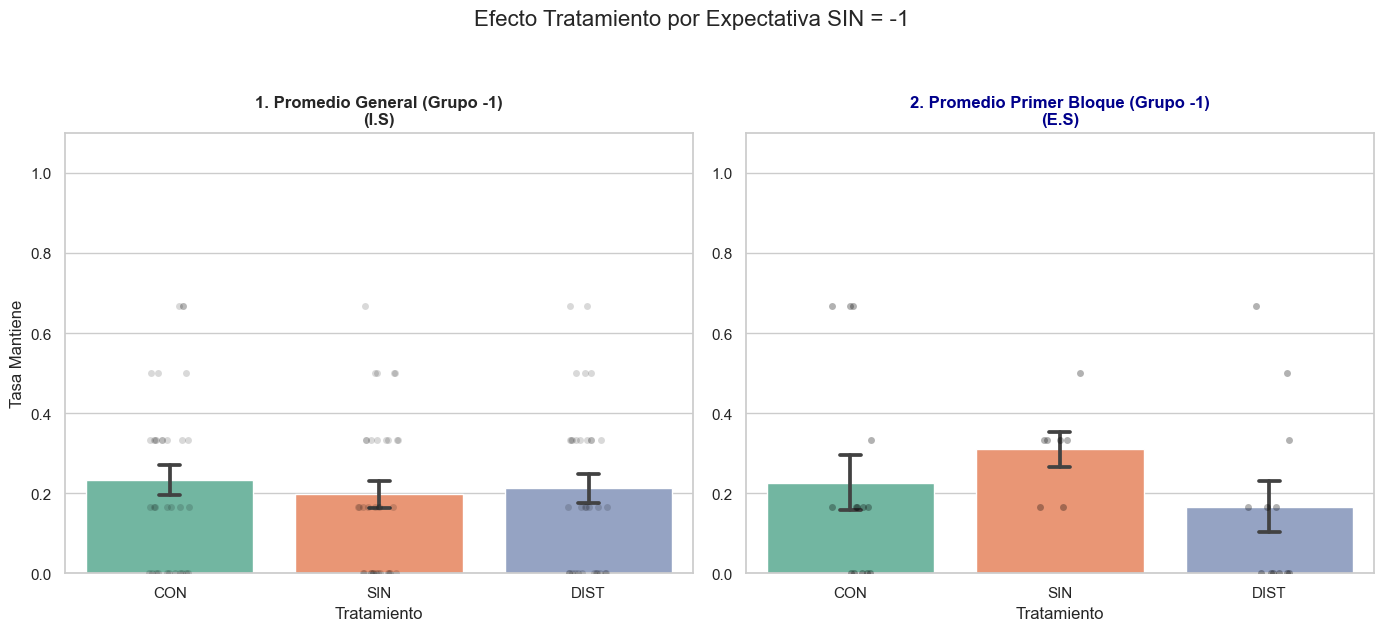

--- RESULTADOS GRUPO -1 ---

1. Intra-sujetos (Resumen):
             count   mean    sem
Tratamiento                     
CON             33  0.232  0.038
SIN             33  0.197  0.034
DIST            33  0.212  0.036

2. Entre-sujetos (Primer Bloque):
             count   mean    sem
Tratamiento                     
CON             14  0.226  0.069
SIN              7  0.310  0.043
DIST            12  0.167  0.065



 ANÁLISIS PARA: expectativa_sin_num = 0


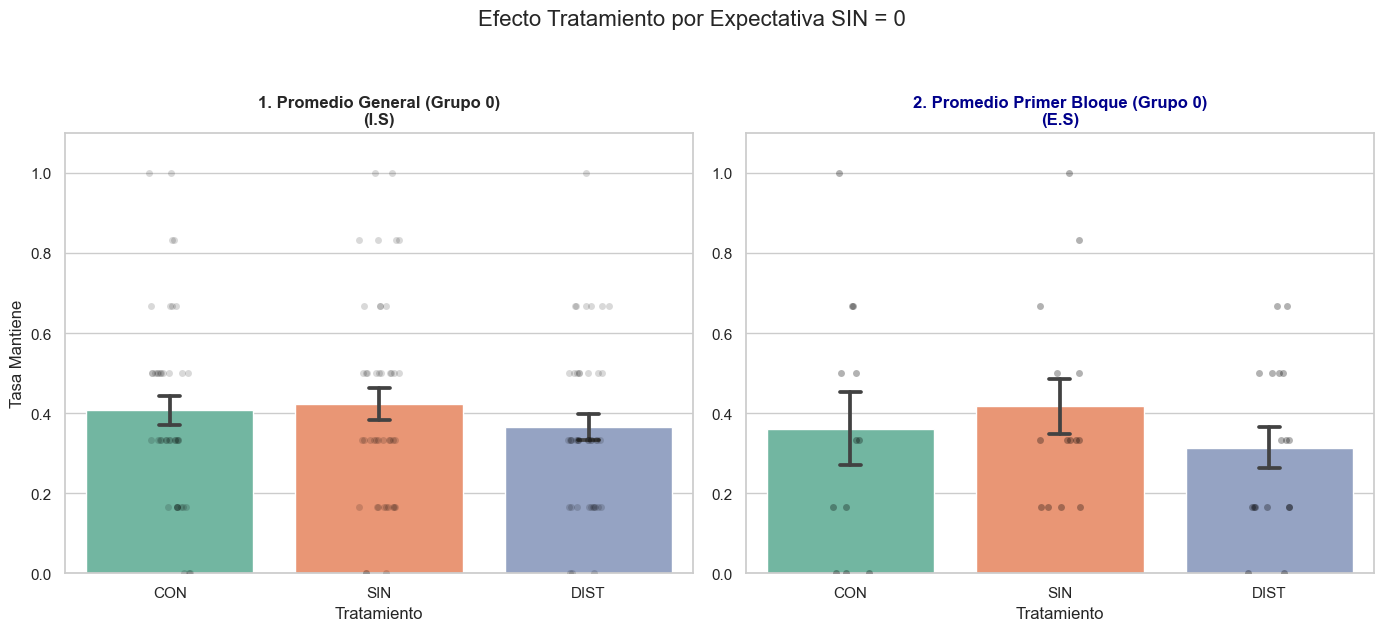

--- RESULTADOS GRUPO 0 ---

1. Intra-sujetos (Resumen):
             count   mean    sem
Tratamiento                     
CON             43  0.407  0.037
SIN             43  0.422  0.040
DIST            43  0.364  0.032

2. Entre-sujetos (Primer Bloque):
             count   mean    sem
Tratamiento                     
CON             12  0.361  0.091
SIN             14  0.417  0.069
DIST            17  0.314  0.051



 ANÁLISIS PARA: expectativa_sin_num = 1


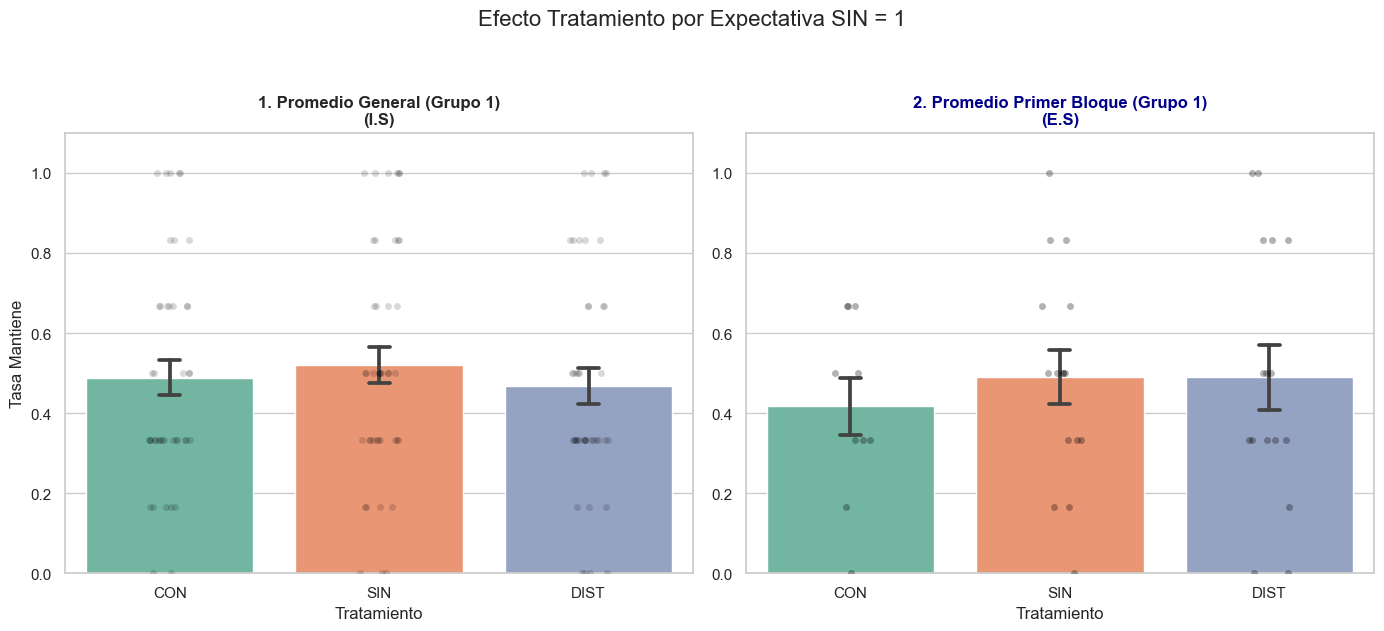

--- RESULTADOS GRUPO 1 ---

1. Intra-sujetos (Resumen):
             count   mean    sem
Tratamiento                     
CON             42  0.488  0.043
SIN             42  0.520  0.046
DIST            42  0.468  0.044

2. Entre-sujetos (Primer Bloque):
             count   mean    sem
Tratamiento                     
CON             10  0.417  0.071
SIN             16  0.490  0.067
DIST            16  0.490  0.081




In [3]:


# --- LIMPIEZA DE DUPLICADOS EN df_long ---
df_long = df_long.drop_duplicates(subset=['ID_Sujeto', 'Orden_1', 'Orden_2'], keep='first').copy()

# 2. Preprocesamiento
df_long['Tratamiento'] = df_long['Dilema'].str.upper().str.extract('(CON|SIN|DIST)', expand=False)

# Definir columna de agrupación
col_grupo = 'expectativa_sin_num'

# Verificar que la columna exista
if col_grupo not in df_long.columns:
    print(f"Error: {col_grupo} no está en df_long")
else:
    grupos = sorted(df_long[col_grupo].dropna().unique())
    print(f"Grupos encontrados en {col_grupo}: {grupos}")

    # Iterar por cada grupo
    for grupo in grupos:
        print(f"\n{'='*80}")
        print(f" ANÁLISIS PARA: {col_grupo} = {grupo}")
        print(f"{'='*80}")
        
        # Filtrar df_long para este grupo
        df_long_grupo = df_long[df_long[col_grupo] == grupo].copy()
        ids_grupo = df_long_grupo['ID_Sujeto'].unique()
        
        # Filtrar df_resumen para los mismos sujetos (para consistencia)
        df_resumen_grupo = df_resumen[df_resumen['ID_Sujeto'].isin(ids_grupo)].copy()
        
        # --- PREPARACIÓN DE DATOS ---
        
        # A. Panel 1: Promedio General (Desde df_resumen)
        # Melt
        df_panel1 = df_resumen_grupo.melt(
            id_vars='ID_Sujeto', 
            value_vars=['Promedio_CON', 'Promedio_SIN', 'Promedio_DIST'],
            var_name='Tratamiento', 
            value_name='Mantiene'
        )
        df_panel1['Tratamiento'] = df_panel1['Tratamiento'].str.replace('Promedio_', '')
        
        # B. Panel 2: Promedio Primer Tratamiento (Desde df_long)
        df_panel2 = df_long_grupo[df_long_grupo['Orden_1'] == 1].groupby(['ID_Sujeto', 'Tratamiento'])['Mantiene'].mean().reset_index()
        
        # --- VISUALIZACIÓN ---
        orden = ['CON', 'SIN', 'DIST']
        sns.set_theme(style="whitegrid")
        
        # Configuramos solo 2 columnas
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        
        # Panel 1
        sns.barplot(data=df_panel1, x='Tratamiento', y='Mantiene', order=orden, 
                    palette='Set2', errorbar='se', capsize=.1, ax=axes[0])
        sns.stripplot(data=df_panel1, x='Tratamiento', y='Mantiene', order=orden, 
                      color='black', alpha=0.15, jitter=True, ax=axes[0])
        axes[0].set_title(f'1. Promedio General (Grupo {grupo})\n(I.S)', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Tasa Mantiene')
        axes[0].set_ylim(0, 1.1)
        
        # Panel 2
        sns.barplot(data=df_panel2, x='Tratamiento', y='Mantiene', order=orden, 
                    palette='Set2', errorbar='se', capsize=.1, ax=axes[1])
        sns.stripplot(data=df_panel2, x='Tratamiento', y='Mantiene', order=orden, 
                      color='black', alpha=0.3, jitter=True, ax=axes[1])
        axes[1].set_title(f'2. Promedio Primer Bloque (Grupo {grupo})\n(E.S)', fontsize=12, fontweight='bold', color='darkblue')
        axes[1].set_ylabel('')
        axes[1].set_ylim(0, 1.1)
        
        plt.suptitle(f'Efecto Tratamiento por Expectativa SIN = {grupo}', fontsize=16, y=1.05)
        plt.tight_layout()
        filename = f'panel_doble_expsin_{grupo}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        
        # --- TABLAS ---
        print(f"--- RESULTADOS GRUPO {grupo} ---")
        print("\n1. Intra-sujetos (Resumen):")
        print(df_panel1.groupby('Tratamiento')['Mantiene'].agg(['count', 'mean', 'sem']).reindex(orden).round(3))
        
        print("\n2. Entre-sujetos (Primer Bloque):")
        print(df_panel2.groupby('Tratamiento')['Mantiene'].agg(['count', 'mean', 'sem']).reindex(orden).round(3))
        print("\n")